# 08 — Walk-Forward Backtest (การทดสอบแบบเลื่อนหน้าต่างเวลา)

รัน harness ของ Phase 8: หน้าต่าง **anchored walk-forward** (ไม่ใช่ random/k-fold เด็ดขาด — กฎ #6) ขับ
เครื่องคิดความเสี่ยง Phase 7 ทับสัญญาณ/การส่งคำสั่ง Phase 5 พร้อม **โมเดลต้นทุนจริง** (commission + slippage + spread)

**ข้อมูล:** อ่าน OHLCV จาก snapshot Parquet ภายในเครื่องเท่านั้น — ไม่ดึง tvkit

> **Risk mitigation:** โน้ตบุ๊กนี้สาธิตการคุม drawdown — ปิด Strategy C, เหลือ ORB (B) เป็นแกน, gate เฉพาะ regime `trend_up`, ขยาย ATR stop เป็น 2.0, ลดความเสี่ยงต่อไม้เป็น 0.5% และเพิ่ม circuit breaker −5R ต่อหน้าต่าง เซลล์ before/after ด้านล่างเทียบ drawdown ก่อน/หลัง

> **Data gate:** ตัวเลข exit-criteria จริงยัง **เลื่อนออกไป (data-gated)** จนกว่าจะมี backfill TFEX 5 ปี — โน้ตบุ๊กนี้สาธิต *กลไก* บน snapshot ภายในเครื่อง

In [1]:
import polars as pl

from tfex_s50_multi_tf_swing.backtest.data_source import build_execution_bars, load_continuous_frames
from tfex_s50_multi_tf_swing.backtest.models import WalkForwardConfig
from tfex_s50_multi_tf_swing.backtest.walk_forward import run_walk_forward
from tfex_s50_multi_tf_swing.config.settings import get_settings
from tfex_s50_multi_tf_swing.data.store import ParquetStore
from tfex_s50_multi_tf_swing.execution.models import ExecutionConfig
from tfex_s50_multi_tf_swing.risk.models import LadderEvidence, RiskConfig
from tfex_s50_multi_tf_swing.signals import strategy_a, strategy_b, strategy_c
from tfex_s50_multi_tf_swing.signals.gate import build_detect_map
from tfex_s50_multi_tf_swing.signals.inputs import build_signal_inputs

In [2]:
# Load the local snapshot WITH 4h so ORB (Strategy B) can fire; build aligned inputs + raw bars.
# (The engine SOURCE declines 4h; the local Parquet snapshot has it — this is a snapshot demo.)
settings = get_settings()
store = ParquetStore(settings.data_dir)
frames = load_continuous_frames(store, with_4h=True)
sig_cfg = settings.signal_config()
inputs = build_signal_inputs(
    frames,
    regime_thresholds=settings.regime_thresholds(),
    bias_config=settings.bias_config(),
    signal_config=sig_cfg,
)
raw_bars = build_execution_bars(frames["5m"])  # stand-in for raw per-contract until TFEX backfill

# Walk-forward windows sized to this ~14-month snapshot (the 5-year backfill uses the production
# 3y-train / 1y-test defaults; the 1095d default train would yield 0 windows here).
WF = WalkForwardConfig(train_span_days=240, test_span_days=90, step_days=90)

# A backtest measures scaled-capacity edge, so evaluate at the `scale` rung with full evidence
# (the live ladder stays env-gated; `paper` caps to 0 contracts and would take no trades).
EVIDENCE = LadderEvidence(months_live=120.0, expectancy_stable=True, drawdown_within_budget=True)


def backtest_risk(**overrides: object) -> RiskConfig:
    """Settings risk config forced to the `scale` rung, with optional field overrides."""
    base = settings.risk_config().model_dump()
    base["deployment_stage"] = "scale"
    base.update(overrides)
    return RiskConfig(**base)


# MITIGATED active pool: config-driven (default B-only, trend_up-gated) via build_detect_map.
detect = build_detect_map(
    sig_cfg, enabled=settings.enabled_strategy_ids(), allowed_regimes=sig_cfg.allowed_regimes
)
print("active strategies:", sorted(detect), "| entry regimes:", sorted(sig_cfg.allowed_regimes))

# Pre-mitigation baseline pool: A + B + C, no regime gate (used by the before/after comparison).
detect_unmitigated = {
    "A": lambda df: strategy_a.to_signals(strategy_a.classify_frame(df, config=sig_cfg)),
    "B": lambda df: strategy_b.to_signals(strategy_b.classify_frame(df, config=sig_cfg)),
    "C": lambda df: strategy_c.to_signals(strategy_c.classify_frame(df, config=sig_cfg)),
}

active strategies: ['B'] | entry regimes: ['trend_up']


In [3]:
# Run the anchored walk-forward with the MITIGATED config: combined (shared session) + per-strategy.
report = run_walk_forward(
    inputs=inputs,
    raw_bars=raw_bars,
    detect=detect,
    wf_config=WF,
    exec_config=settings.execution_config(),  # k_atr_stop=2.0 default (widened)
    risk_config=backtest_risk(),  # risk_per_trade_pct=0.005 + per-window -5R breaker defaults
    cost_model=settings.cost_model(),
    ladder_evidence=EVIDENCE,
)
print(f"windows: {len(report.windows)}")
for sid, res in {"combined": report.combined, **report.per_strategy}.items():
    print(sid, "n_trades", res.overall.n_trades, "expectancy_r", float(res.overall.expectancy_r),
          "max_dd_r", float(res.drawdown.depth_r), "sharpe", res.ratios.sharpe)

windows: 3
combined n_trades 7 expectancy_r -0.022698353976604385 max_dd_r 1.8864044784158016 sharpe -0.022895388139677057
A n_trades 0 expectancy_r 0.0 max_dd_r 0.0 sharpe None
B n_trades 7 expectancy_r -0.022698353976604385 max_dd_r 1.8864044784158016 sharpe -0.022895388139677057
C n_trades 0 expectancy_r 0.0 max_dd_r 0.0 sharpe None


## Before / after — drawdown control (การคุมการขาดทุนสะสม)

เทียบ **ก่อน** (A+B+C, ไม่มี regime gate, k_atr_stop=1.5, เสี่ยง 1%, ไม่มี circuit breaker — ตัวขับ 31.13R เดิม)
กับ **หลัง** (B อย่างเดียว + gate เฉพาะ `trend_up`, k_atr_stop=2.0, เสี่ยง 0.5%, circuit breaker −5R ต่อหน้าต่าง)
บน snapshot และหน้าต่างเดียวกัน

In [4]:
# BEFORE = pre-mitigation setup; AFTER = the mitigated `report` above. Same snapshot + windows.
before_exec = ExecutionConfig(**{**settings.execution_config().model_dump(), "k_atr_stop": 1.5})
before = run_walk_forward(
    inputs=inputs,
    raw_bars=raw_bars,
    detect=detect_unmitigated,
    wf_config=WF,
    exec_config=before_exec,
    # 1% risk + breaker effectively off (large negative floor) reproduce the old behaviour.
    risk_config=backtest_risk(risk_per_trade_pct=0.01, per_window_loss_limit_r=-1e9),
    cost_model=settings.cost_model(),
    ladder_evidence=EVIDENCE,
)

comparison = pl.DataFrame(
    [
        {
            "config": "before (A+B+C; no gate; k=1.5; 1%; no breaker)",
            "n_trades": before.combined.overall.n_trades,
            "max_dd_r": round(float(before.combined.drawdown.depth_r), 2),
            "expectancy_r": round(float(before.combined.overall.expectancy_r), 4),
        },
        {
            "config": "after (B-only; trend_up gate; k=2.0; 0.5%; -5R breaker)",
            "n_trades": report.combined.overall.n_trades,
            "max_dd_r": round(float(report.combined.drawdown.depth_r), 2),
            "expectancy_r": round(float(report.combined.overall.expectancy_r), 4),
        },
    ]
)
print(comparison)
print(
    "\nmax drawdown:",
    f"{float(before.combined.drawdown.depth_r):.2f}R  ->  {float(report.combined.drawdown.depth_r):.2f}R",
)

kill switch ENGAGED: daily_loss_limit — flatten + halt


kill switch ENGAGED: daily_loss_limit — flatten + halt


kill switch ENGAGED: daily_loss_limit — flatten + halt


kill switch ENGAGED: daily_loss_limit — flatten + halt


kill switch ENGAGED: daily_loss_limit — flatten + halt


...

kill switch ENGAGED: daily_loss_limit — flatten + halt


kill switch ENGAGED: daily_loss_limit — flatten + halt


kill switch ENGAGED: daily_loss_limit — flatten + halt


kill switch ENGAGED: daily_loss_limit — flatten + halt


shape: (2, 4)
┌─────────────────────────────────┬──────────┬──────────┬──────────────┐
│ config                          ┆ n_trades ┆ max_dd_r ┆ expectancy_r │
│ ---                             ┆ ---      ┆ ---      ┆ ---          │
│ str                             ┆ i64      ┆ f64      ┆ f64          │
╞═════════════════════════════════╪══════════╪══════════╪══════════════╡
│ before (A+B+C; no gate; k=1.5;… ┆ 325      ┆ 31.13    ┆ 0.0434       │
│ after (B-only; trend_up gate; … ┆ 7        ┆ 1.89     ┆ -0.0227      │
└─────────────────────────────────┴──────────┴──────────┴──────────────┘

max drawdown: 31.13R  ->  1.89R


## เส้นทุน (NAV indexed = 100) ต่อหน้าต่าง + drawdown + circuit breaker

NAV ดัชนีฐาน 100 ต่อหน้าต่าง ความลึก drawdown (R) และธงว่าหน้าต่างไหนโดน circuit breaker ตัด

shape: (3, 5)
┌────────┬────────────┬──────────┬─────────┬─────────────────┐
│ window ┆ nav_index  ┆ max_dd_r ┆ n_taken ┆ breaker_tripped │
│ ---    ┆ ---        ┆ ---      ┆ ---     ┆ ---             │
│ i64    ┆ f64        ┆ f64      ┆ i64     ┆ bool            │
╞════════╪════════════╪══════════╪═════════╪═════════════════╡
│ 0      ┆ 99.837888  ┆ 1.886404 ┆ 3       ┆ false           │
│ 1      ┆ 100.010488 ┆ 1.150057 ┆ 4       ┆ false           │
│ 2      ┆ 100.0      ┆ 0.0      ┆ 0       ┆ false           │
└────────┴────────────┴──────────┴─────────┴─────────────────┘


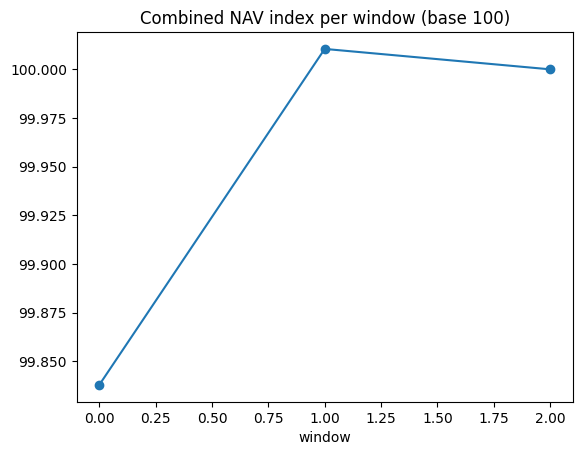

In [5]:
# Per-window NAV index, drawdown depth, and the circuit-breaker flag (public-safe: no raw OHLCV).
rows = [
    {
        "window": w.window.index,
        "nav_index": w.nav_index,
        "max_dd_r": float(w.drawdown.depth_r),
        "n_taken": w.n_taken,
        "breaker_tripped": w.circuit_breaker_tripped,
    }
    for w in report.combined.windows
]
nav_df = pl.DataFrame(rows)
print(nav_df)
if nav_df.height:
    _p = nav_df.to_pandas().set_index("window")
    _p["nav_index"].plot(title="Combined NAV index per window (base 100)", marker="o")

## Sensitivity sweep — ATR-stop multiplier

กวาดค่า `k_atr_stop` 3 ค่าเพื่อดูความไวของ expectancy รวม (พูลที่ปรับลดความเสี่ยงแล้ว — B อย่างเดียว)

In [6]:
# Sweep the most influential execution threshold on the mitigated pool.
sweep = []
base_exec = settings.execution_config()
for k in (1.0, 1.5, 2.0):
    exec_cfg = ExecutionConfig(**{**base_exec.model_dump(), "k_atr_stop": k})
    rep = run_walk_forward(
        inputs=inputs, raw_bars=raw_bars, detect=detect,
        wf_config=WF, exec_config=exec_cfg,
        risk_config=backtest_risk(), cost_model=settings.cost_model(),
        ladder_evidence=EVIDENCE,
    )
    sweep.append({"k_atr_stop": k, "n_trades": rep.combined.overall.n_trades,
                  "expectancy_r": float(rep.combined.overall.expectancy_r)})
print(pl.DataFrame(sweep))

shape: (3, 3)
┌────────────┬──────────┬──────────────┐
│ k_atr_stop ┆ n_trades ┆ expectancy_r │
│ ---        ┆ ---      ┆ ---          │
│ f64        ┆ i64      ┆ f64          │
╞════════════╪══════════╪══════════════╡
│ 1.0        ┆ 7        ┆ -0.022698    │
│ 1.5        ┆ 7        ┆ -0.022698    │
│ 2.0        ┆ 7        ┆ -0.022698    │
└────────────┴──────────┴──────────────┘


## สรุป

- **Risk mitigation:** ปิด C, เหลือ ORB เป็นแกน, gate `trend_up`, ATR stop 2.0, เสี่ยง 0.5%, circuit breaker −5R
- เซลล์ before/after แสดง max drawdown ลดลงชัดเจนบน snapshot เดียวกัน
- harness / cost model / metrics / risk engine (Phase 7) ทำงานครบ (shared daily session ในรันรวม)
- **ตัวเลขผลลัพธ์จริงยังเลื่อนออกไป (data-gated)** จนกว่าจะมี backfill TFEX 5 ปี
- artifact สาธารณะเขียนโดย `scripts/run_walk_forward.py` -> `results/static/backtest/walk_forward.json`